In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
dataset_path = "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data"

In [3]:
import os

print(os.listdir(dataset_path))

['Tomato', 'Persimmon', 'Orange', 'Guava', 'Palm', 'Fig', 'Berry', 'Apple']


In [4]:
apple_path  = "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Apple"
berry_path  = "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Berry"
guava_path  = "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Guava"
orange_path = "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Orange"

In [5]:
# MULTI LABEL FRUIT CLASSIFICATION
# STEP 1 : IMPORT LIBRARIES

import os
import cv2
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [6]:

# STEP 2 : DATASET PATHS

apple_path  = "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Apple"
berry_path  = "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Berry"
guava_path  = "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Guava"
orange_path = "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Orange"

IMG_SIZE = 64


In [7]:


# STEP 3 : LOAD IMAGES

def load_images(folder):

    images = []

    for img_name in os.listdir(folder):

        path = os.path.join(folder, img_name)

        image = cv2.imread(path)

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        images.append(image)

    return images


apple  = load_images(apple_path)
berry  = load_images(berry_path)
guava  = load_images(guava_path)
orange = load_images(orange_path)

print("Apple :", len(apple))
print("Berry :", len(berry))
print("Guava :", len(guava))
print("Orange:", len(orange))

Apple : 519
Berry : 340
Guava : 520
Orange: 547


In [8]:

# STEP 4 : CREATE MULTI LABEL DATA

data = []
labels = []


def combine_images(img1, img2):

    return cv2.addWeighted(img1, 0.5, img2, 0.5, 0)



# SINGLE LABELS

for img in apple:
    data.append(img)
    labels.append([1,0,0,0])

for img in berry:
    data.append(img)
    labels.append([0,1,0,0])

for img in guava:
    data.append(img)
    labels.append([0,0,1,0])

for img in orange:
    data.append(img)
    labels.append([0,0,0,1])



# TWO LABELS

for _ in range(500):

    data.append(
        combine_images(
            random.choice(apple),
            random.choice(berry)
        )
    )
    labels.append([1,1,0,0])

    data.append(
        combine_images(
            random.choice(apple),
            random.choice(guava)
        )
    )
    labels.append([1,0,1,0])

    data.append(
        combine_images(
            random.choice(apple),
            random.choice(orange)
        )
    )
    labels.append([1,0,0,1])

    data.append(
        combine_images(
            random.choice(berry),
            random.choice(guava)
        )
    )
    labels.append([0,1,1,0])

    data.append(
        combine_images(
            random.choice(berry),
            random.choice(orange)
        )
    )
    labels.append([0,1,0,1])

    data.append(
        combine_images(
            random.choice(guava),
            random.choice(orange)
        )
    )
    labels.append([0,0,1,1])



# THREE LABELS

for _ in range(300):

    data.append(
        combine_images(
            combine_images(
                random.choice(apple),
                random.choice(berry)
            ),
            random.choice(guava)
        )
    )
    labels.append([1,1,1,0])

    data.append(
        combine_images(
            combine_images(
                random.choice(apple),
                random.choice(berry)
            ),
            random.choice(orange)
        )
    )
    labels.append([1,1,0,1])

    data.append(
        combine_images(
            combine_images(
                random.choice(apple),
                random.choice(guava)
            ),
            random.choice(orange)
        )
    )
    labels.append([1,0,1,1])

    data.append(
        combine_images(
            combine_images(
                random.choice(berry),
                random.choice(guava)
            ),
            random.choice(orange)
        )
    )
    labels.append([0,1,1,1])



# FOUR LABELS

for _ in range(200):

    data.append(
        combine_images(
            combine_images(
                random.choice(apple),
                random.choice(berry)
            ),
            combine_images(
                random.choice(guava),
                random.choice(orange)
            )
        )
    )

    labels.append([1,1,1,1])


In [9]:

# STEP 5 : CONVERT TO NUMPY

data = np.array(data)
labels = np.array(labels)

print("Final Data Shape  :", data.shape)
print("Final Label Shape :", labels.shape)

Final Data Shape  : (6326, 64, 64, 3)
Final Label Shape : (6326, 4)


In [10]:

# STEP 6 : NORMALIZE + SPLIT

data = data / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)



In [11]:

# STEP 7: CNN MODEL

model = models.Sequential()

# Input Layer
model.add(
    layers.Input(shape=(64,64,3))
)

# First CNN Layer
model.add(
    layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    )
)

model.add(
    layers.MaxPooling2D((2,2))
)

# Second CNN Layer
model.add(
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    layers.MaxPooling2D((2,2))
)

# Third CNN Layer
model.add(
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Flatten
model.add(
    layers.Flatten()
)

# Dense Layer
model.add(
    layers.Dense(
        64,
        activation='relu'
    )
)

# Dropout Layer
model.add(
    layers.Dropout(0.3)
)

# Output Layer
model.add(
    layers.Dense(
        4,
        activation='sigmoid'
    )
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,468 (2.47 MB)

 Trainable params: 646,468 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:

# STEP 8 : COMPILE MODEL

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)


In [13]:

# STEP 9 : TRAIN MODEL

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_data=(X_test, y_test)
)


Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - binary_accuracy: 0.6795 - loss: 0.5688 - val_binary_accuracy: 0.8006 - val_loss: 0.4054
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.8115 - loss: 0.3954 - val_binary_accuracy: 0.8683 - val_loss: 0.3072
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.8557 - loss: 0.3172 - val_binary_accuracy: 0.9013 - val_loss: 0.2425
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.8766 - loss: 0.2751 - val_binary_accuracy: 0.8863 - val_loss: 0.2485
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.8866 - loss: 0.2560 - val_binary_accuracy: 0.9153 - val_loss: 0.2104
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.9037 - loss: 0.2250 - val_binary_accuracy: 0.9151 - val_loss: 0.1940
Epoch 7/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.9127 - loss: 0.2043 - val_binary_accuracy: 0.9250 - val_loss: 0.1758
Epoc

In [14]:

# STEP 10 : SAVE MODEL

model.save("/content/fruit_model.keras")

print("Model Saved Successfully")


Model Saved Successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


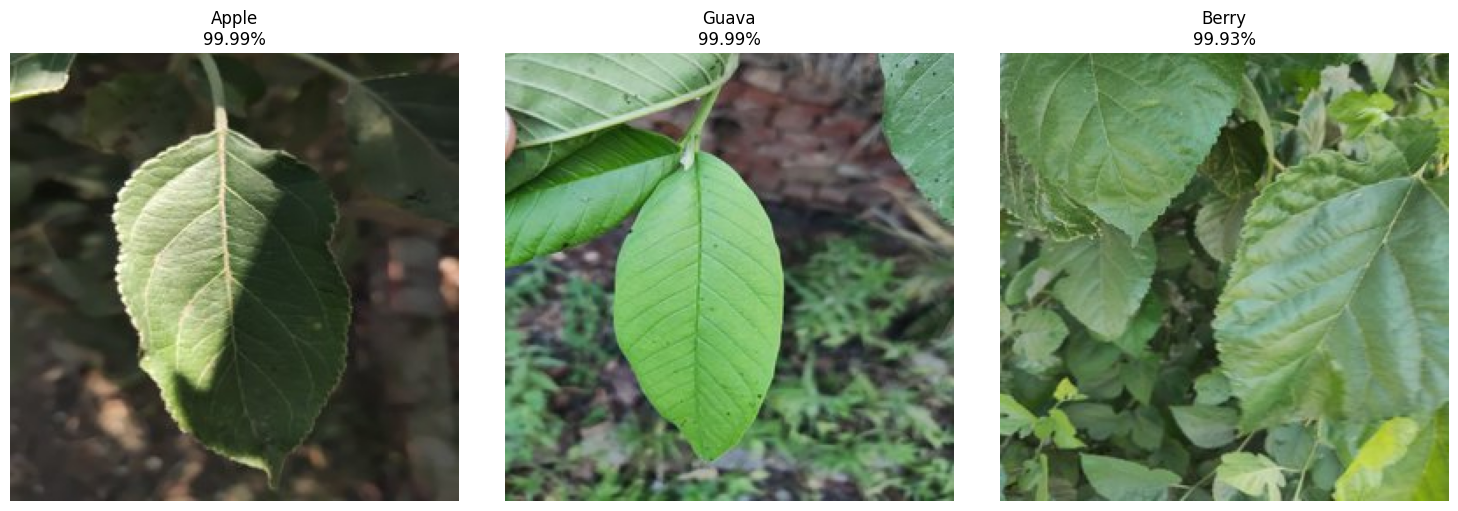

In [16]:
# STEP 11: PREDICTION FOR 3 DIFFERENT IMAGES

class_names = ["Apple", "Berry", "Guava", "Orange"]

# 3 IMAGE PATHS


image_paths = [
    "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Apple/IMG_20240710_161209_2.jpg",
    "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Guava/IMG_20240710_172541.jpg",
    "/content/drive/MyDrive/Egyptian _Plant _Leaf/New_data/Berry/IMG_20240702_163356.jpg"
]


# DISPLAY IMAGES


plt.figure(figsize=(15,5))

for i, img_path in enumerate(image_paths):

    img = cv2.imread(img_path)

    if img is None:

        print(f"Image Not Found: {img_path}")
        continue

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize for model
    img_resized = cv2.resize(img, (64,64))

    # Normalize
    img_resized = img_resized / 255.0

    # Expand Dimension
    img_resized = np.expand_dims(img_resized, axis=0)

    # Predict
    prediction = model.predict(img_resized)[0]

    # Best Prediction
    predicted_index = np.argmax(prediction)

    label = class_names[predicted_index]

    confidence = prediction[predicted_index] * 100


    # SHOW IMAGE


    plt.subplot(1, 3, i+1)

    plt.imshow(img_rgb)

    plt.title(f"{label}\n{confidence:.2f}%")

    plt.axis("off")

plt.tight_layout()

plt.show()